# Coordination and Resource Allocation Under Water Scarcity During Heatwaves: An LLM-Based Multi-Agent Simulation

This simulation models **institutional stakeholders negotiating over a shared, shrinking water supply** during a severe multi-day heatwave in Germany.

**Research question:** how do autonomous LLM-based agents coordinate the allocation of scarce water resources during a heatwave — when do they cooperate, compete, and adapt?


### What lives where

| Mechanism | Location |
|---|---|
| LLM helpers, cache, cost tracker | `water_scarcity_sim.py` §1 |
| Water supply schedule + demand escalation | §2 |
| Stakeholder profiles + negotiation topology | §3 |
| Negotiation protocol + deterministic clearing | §4 |
| Memory stream + importance + retrieval | §5 |
| Reflection on importance threshold | §6 |
| Need estimation / negotiation moves / authority ruling | §7 |
| `RunConfig`, simulation engine, `run_batch`, metrics | §8 |

Design principle: **Use arithmetic deterministic** (supply, demand, allocation clearing, metrics) and let the LLM decide *behavior* on top of it, e.g., what to request, how to argue, whether to concede. The clearing function, not any LLM call, is what guarantees allocations never exceed supply.

**Experiment contract:** every `run_simulation(config)` call returns exactly `(decisions_df, outcomes_df, agents)`, process-level moves, outcome-level results, and memory streams for qualitative drill-down. Everything you'd want to vary between experimental conditions (supply schedule, negotiation cap, priority weights, demand level, seed) lives in a `RunConfig`, so sweeping conditions means constructing several `RunConfig`s and calling `run_batch()`, never editing module constants between runs.


In [1]:
import water_scarcity_sim as sim
import pandas as pd
import matplotlib.pyplot as plt


---
## 1. Stakeholders and negotiation topology

Seven institutional stakeholders: one arbiter (the Water Authority), five demanders, and one advocate (the Environmental Protection Agency, which argues for an ecological reserve rather than consuming water itself).


In [2]:
for s in sim.STAKEHOLDERS:
    print(f'{s.id:16} role={s.role:9} priority_weight={s.priority_weight}')

print('\nNegotiation topology (peer-to-peer trade links, in addition to the implicit hub link '
      'every demander has to the Water Authority):')
for k, v in sim.NEGOTIATION_TOPOLOGY.items():
    if v:
        print(f'  {k} <-> {v}')


water_authority  role=arbiter   priority_weight=0.0
hospital         role=demander  priority_weight=5.0
households       role=demander  priority_weight=3.0
agriculture      role=demander  priority_weight=2.0
industry         role=demander  priority_weight=1.0
energy_utility   role=demander  priority_weight=4.0
epa              role=advocate  priority_weight=1.5

Negotiation topology (peer-to-peer trade links, in addition to the implicit hub link every demander has to the Water Authority):
  agriculture <-> ['industry']
  industry <-> ['agriculture', 'energy_utility']
  energy_utility <-> ['industry']
  water_authority <-> ['hospital', 'households', 'agriculture', 'industry', 'energy_utility', 'epa']


---
## 2. World model: shrinking supply, rising temperature, rising demand

Total daily supply shrinks over the heatwave while peak temperature rises and falls across it (`TEMPERATURE_SCHEDULE`). Each demander's *physical/operational* need (not its strategic request) escalates deterministically by a fixed daily factor — this is the "physics" layer, analogous to the original sim's temperature model. It is **not** an LLM decision.

Temperature itself is currently narrative/contextual: it's surfaced directly in every LLM prompt (need estimation, negotiation moves, the Authority's ruling) so stakeholders' arguments can reference real conditions, and it's recorded in `outcomes_df` for analysis — but `demand_escalation()` is still day-index-based, not temperature-based, so heat severity and demand growth are aligned by design, not mechanically linked. Rebasing escalation on temperature instead of day is a reasonable later step if you want the physics itself to be heat-driven.


In [3]:
rows = []
for day in range(sim.N_DAYS):
    row = {'day': day, 'supply': sim.total_supply(day), 'peak_temp_c': sim.total_temperature(day)}
    for sid in sim.DEMANDER_IDS:
        row[sid] = sim.demand_today(sid, day)
    rows.append(row)
demand_df = pd.DataFrame(rows).set_index('day')
demand_df


,supply,peak_temp_c,hospital,households,agriculture,industry,energy_utility,epa
day,,,,,,,,
0,600.0,36.0,147.0,388.0,237.5,150.0,96.0,80.0
1,1000.0,34.0,150.0,400.0,250.0,150.0,100.0,80.0
2,900.0,37.0,153.0,412.0,262.5,150.0,104.0,80.0
3,800.0,40.0,156.0,424.0,275.0,150.0,108.0,80.0
4,700.0,41.0,159.0,436.0,287.5,150.0,112.0,80.0
5,650.0,39.0,162.0,448.0,300.0,150.0,116.0,80.0


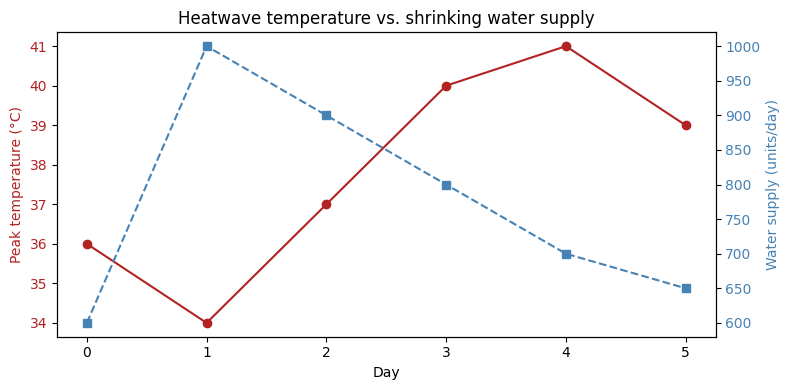

In [4]:
fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(demand_df.index, demand_df['peak_temp_c'], color='firebrick', marker='o', label='Peak temperature (°C)')
ax1.set_xlabel('Day')
ax1.set_ylabel('Peak temperature (°C)', color='firebrick')
ax1.tick_params(axis='y', labelcolor='firebrick')

ax2 = ax1.twinx()
ax2.plot(demand_df.index, demand_df['supply'], color='steelblue', marker='s', linestyle='--', label='Water supply (units)')
ax2.set_ylabel('Water supply (units/day)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

plt.title('Heatwave temperature vs. shrinking water supply')
fig.tight_layout()
plt.show()


Temperature and supply aren't mechanically linked yet (see note above), but plotting them together is a useful sanity check that the narrative ('a severe heatwave drives water scarcity') is at least *consistent* — heat peaking mid-week lines up with supply hitting its low point.


Note that by Day 2, total baseline demand already exceeds supply for the first time — this is what makes scarcity, and therefore negotiation, emerge from the numbers rather than being scripted to happen on a particular day.


In [5]:
total_demand = demand_df[sim.DEMANDER_IDS].sum(axis=1)
comparison = pd.DataFrame({'supply': demand_df['supply'], 'total_baseline_demand': total_demand})
comparison['shortfall'] = comparison['total_baseline_demand'] - comparison['supply']
comparison


,supply,total_baseline_demand,shortfall
day,,,
0,600.0,1098.5,498.5
1,1000.0,1130.0,130.0
2,900.0,1161.5,261.5
3,800.0,1193.0,393.0
4,700.0,1224.5,524.5
5,650.0,1256.0,606.0


---
## 3. Deterministic clearing — the fast pass, no LLM involved

`clear_allocation()` is a two-phase deterministic algorithm: guarantee minimums in priority order, then split anything left over proportional to priority-weighted unmet request. It is used both for the daily fast pass *and* after negotiation, the LLM never does this arithmetic itself, and a final rounding-safety clamp guarantees the total never exceeds supply even after per-stakeholder rounding.

This cell needs no API key, it demonstrates the clearing/severity logic directly on a hand-built set of requests.


In [6]:
demo_day = 2
demo_requests = {sid: sim.demand_today(sid, demo_day) for sid in sim.DEMANDER_IDS}
demo_min = {sid: sim.min_acceptable_today(sid, demo_day) for sid in sim.DEMANDER_IDS}
demo_weights = {sid: sim.STAKEHOLDER_BY_ID[sid].priority_weight for sid in sim.DEMANDER_IDS}
demo_supply = sim.total_supply(demo_day)

allocation = sim.clear_allocation(demo_requests, demo_min, demo_weights, demo_supply)
affected = sim.check_severity(allocation, demo_min)

print(f'Day {demo_day} fast-pass allocation (supply={demo_supply}):')
for sid in sim.DEMANDER_IDS:
    flag = '  <-- BELOW MINIMUM' if sid in affected else ''
    print(f'  {sid:16} requested={demo_requests[sid]:6.1f} min={demo_min[sid]:6.1f} '
          f'allocated={allocation[sid]:6.1f}{flag}')
print(f'\nTotal allocated: {sum(allocation.values()):.1f} / {demo_supply} '
      f'(must never exceed supply)')
print(f'Escalates to negotiation: {bool(affected)}')


Day 2 fast-pass allocation (supply=900.0):
  hospital         requested= 153.0 min= 130.0 allocated= 140.1
  households       requested= 412.0 min= 309.0 allocated= 336.0
  agriculture      requested= 262.5 min= 157.5 allocated= 175.9
  industry         requested= 150.0 min=  97.5 allocated= 102.1
  energy_utility   requested= 104.0 min=  93.6 allocated=  97.2
  epa              requested=  80.0 min=  44.0 allocated=  48.7

Total allocated: 900.0 / 900.0 (must never exceed supply)
Escalates to negotiation: False


This is the trigger for the mixed-depth design: most days should clear cleanly in this one deterministic pass; negotiation only happens — and only *for the affected stakeholders* — when this fast pass would actually push someone below their stated minimum.


---
## 4. Memory + retrieval

`Memory`, `MemoryStream`, and `retrieve()` are byte-for-byte the same recency+importance+relevance retrieval rule as the original citizen sim. Only the *content* of memories and the `rate_importance` prompt's anchor examples changed (institutional stakes instead of personal poignancy).

**Requires `OPENAI_API_KEY`** (for `embed()`/`llm()`) — skipped automatically if not set.


In [7]:
if sim.client is None:
    print('OPENAI_API_KEY not set — skipping live demo. Set it in your .env to run this cell.')
else:
    s = sim.MemoryStream('demo')
    s.add('Day 1: requested 250 units, received 200 (80% of request).', created_at=1, importance=6)
    s.add('Day 2: Industry refused to reduce consumption despite shortages.', created_at=2, importance=7)
    s.add('Day 2: the Water Authority prioritised hospitals during the previous allocation round.', created_at=2, importance=8)
    top = sim.retrieve(s, 'Who has cooperated with reduced allocations?', now_hours=2, k=2)
    for m in top:
        print(m)


Memory(t=2.0, imp=8, "Day 2: the Water Authority prioritised hospitals during the ...")
Memory(t=2.0, imp=7, "Day 2: Industry refused to reduce consumption despite shorta...")


---
## 5. Running one simulation

`run_simulation(config)` runs the day loop: need estimation → fast-pass clearing → severity check → (if severe) capped negotiation rounds → Authority ruling → outcome computation → memory writes → reflection.

It returns exactly **three** things:
- `decisions_df` : one row per decision *event* (the day's request, and every negotiation move) — process-level: what was asked for, what move was made, what was said.
- `outcomes_df` : one row per (stakeholder, day) — outcome-level: request, allocation, satisfaction, shortfall, critical-failure flag, with day-level supply/severity/ruling fields broadcast onto every row.
- `agents` : memory streams etc., for qualitative drill-down into *this* run. Not part of the stats pipeline — use the two dataframes for that.

**This makes real, billed API calls**. Cached after the first run, same as the original sim.


In [8]:
if sim.client is None:
    print('OPENAI_API_KEY not set — set your key in .env to run this live.')
else:
    config = sim.RunConfig(condition_label='baseline')
    decisions_df, outcomes_df, agents = sim.run_simulation(config, verbose=True)

--- Day 1 (baseline) ---
  Hospital / Healthcare Services req=   150 alloc=   150
  Households                     req=   450 alloc=   395
  Agriculture                    req=   250 alloc=   192
  Industry / Businesses          req=   150 alloc=   108
  Energy Utility                 req=   100 alloc=   100
  Environmental Protection Agency req=    80 alloc=    55
  severity=False rounds=0 imposed=False
--- Day 2 (baseline) ---
  Hospital / Healthcare Services req=   153 alloc=   140
  Households                     req=   430 alloc=   340
  Agriculture                    req=   262 alloc=   176
  Industry / Businesses          req=   150 alloc=   102
  Energy Utility                 req=   104 alloc=    97
  Environmental Protection Agency req=    50 alloc=    45
  severity=False rounds=0 imposed=False
--- Day 3 (baseline) ---
  Hospital / Healthcare Services req=   156 alloc=   133
  Households                     req=   450 alloc=   318
  Agriculture                    req=   275 a

---
## 6. Metrics for one run

`compute_metrics(outcomes_df, decisions_df)` reads only the deterministic allocation ledger, never LLM self-report text, for fairness (Gini), collective welfare (utilitarian mean and Rawlsian minimum), conflicts, compromises, trades, cooperation rate, and critical failures.


In [9]:
if sim.client is None:
    print('OPENAI_API_KEY not set — run the live simulation cell above first.')
else:
    per_run_day, per_run_summary = sim.compute_metrics(outcomes_df, decisions_df)
    print(per_run_summary)   # one row — this run's headline numbers


     run_id condition  seed  n_days  n_negotiation_days  \
0  baseline  baseline   NaN       6                   4   

   n_negotiation_rounds_total  n_conflicts  n_compromises  n_trades_proposed  \
0                           8           20              0                  0   

   cooperation_rate  n_critical_failures  mean_fairness_gini  \
0               0.0                   11               0.278   

   mean_collective_welfare_utilitarian  mean_collective_welfare_rawlsian  \
0                                0.615                             0.227   

   system_stability_gini_std  
0                      0.156  


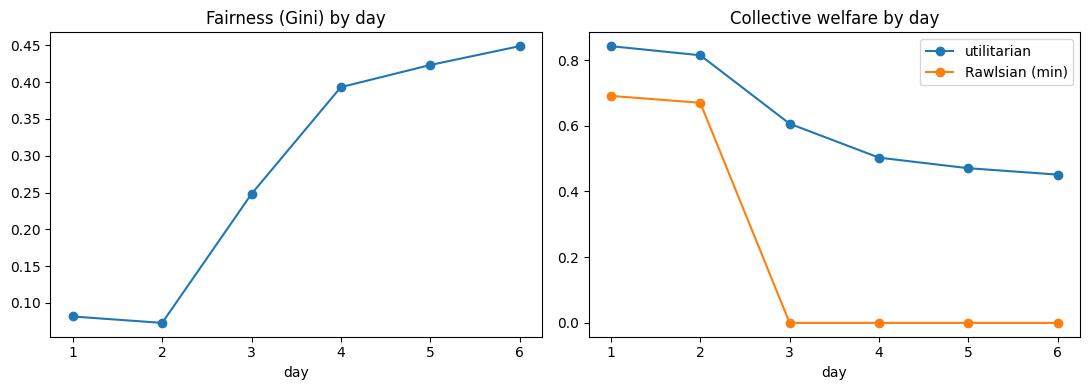

In [10]:
if sim.client is None:
    print('OPENAI_API_KEY not set — run the live simulation cell above first.')
else:
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(per_run_day['day'], per_run_day['fairness_gini'], marker='o')
    ax[0].set_title('Fairness (Gini) by day'); ax[0].set_xlabel('day')
    ax[1].plot(per_run_day['day'], per_run_day['mean_satisfaction'], marker='o', label='utilitarian')
    ax[1].plot(per_run_day['day'], per_run_day['min_satisfaction'], marker='o', label='Rawlsian (min)')
    ax[1].set_title('Collective welfare by day'); ax[1].set_xlabel('day'); ax[1].legend()
    plt.tight_layout(); plt.show()


---
## 7. Running multiple experimental conditions (`run_batch`)

This is the actual payoff of the `RunConfig`/`decisions_df`/`outcomes_df` contract: define a few conditions, run each across several seeds, and aggregate, without ever touching module constants between runs. `RunConfig` objects themselves are free to build (no API calls), so this first cell runs live with no key required.


In [ ]:
conditions = [
    sim.RunConfig(condition_label='baseline_mixed_negotiation'),
    sim.RunConfig(condition_label='deeper_shortage',
                  supply_schedule=[800, 700, 600, 500, 450, 400]),
    sim.RunConfig(condition_label="single_shot_allocation",
                  max_rounds=0,),
    sim.RunConfig(condition_label="no_seeded_precedent",
                  precedent_memories={},),
]

for c in conditions:
    print(f'{c.condition_label:24} n_days={c.n_days}  max_rounds={c.max_rounds}  '
          f'demand_multiplier={c.demand_multiplier}')


`run_batch()` loops conditions × seeds, tags every row with `run_id`/`condition`/`seed`, and concatenates into exactly two dataframes spanning the whole batch. `compute_metrics()` then returns one summary row *per run*, ready for `groupby("condition")`.

**Makes real, billed API calls** — `len(conditions) * n_seeds` full simulations.


In [ ]:
if sim.client is None:
    print('OPENAI_API_KEY not set — set your key in .env to run this live.')
else:
    batch_decisions, batch_outcomes = sim.run_batch(conditions, n_seeds=3)
    per_run_day, per_run_summary = sim.compute_metrics(batch_outcomes, batch_decisions)

    print(per_run_summary.groupby('condition')[
        ['mean_fairness_gini', 'mean_collective_welfare_utilitarian',
         'mean_collective_welfare_rawlsian', 'n_critical_failures', 'cooperation_rate']
    ].agg(['mean', 'std']))   # mean/std ACROSS SEEDS, per condition — the actual research output


`seed` is forwarded to every LLM call in a run (see `llm()` in §1), so re-running the same `RunConfig` with the same seed reproduces the same result, while different seeds genuinely diverge, exactly what a multi-seed convergence check needs, and a feature the original citizen sim only sketched (commented out) without actually wiring up.


---
## 8. Cost tracking


In [ ]:
sim.print_cost_summary()


---
## Notes / open design questions for the next iteration

- Negotiation depth is currently capped at `RunConfig.max_rounds` (default 2); the round-cap outcome is treated as *imposed* if no consensus was reached. Worth checking empirically how often that happens once real runs are in.
- `clear_allocation()` resolves rounding leftovers by trimming the largest allocation; for published results, worth confirming this never silently distorts the headline findings.
- The Water Authority's default priority weights (5/4/3/2/1.5/1, hospital highest) are an explicit normative assumption, not a neutral default — `priority_weight_overrides` makes this a manipulated variable.
- Reflections don't yet feed back into an explicit `strategy` field — they're retrieved passively like any other memory. If deliberate strategy adaptation (rather than emergent-by-luck recall) matters for the write-up, that's the next mechanism to add.
